# 📰 Fake News Detection Using NLP and Machine Learning



## 🧾 Project Steps Overview

Below are the key steps followed in this notebook to develop and deploy an end-to-end **Fake News Detection System**:

---

### 🔹 1. Problem & Project Introduction
- Define the challenge of fake news in media
- Explain project objectives, key stakeholders, and business goals
- Overview of dataset source and structure

---

### 🔹 2. Import Libraries & Load Dataset
- Load `Fake.csv` and `True.csv` datasets
- Add target labels and concatenate into a single DataFrame
- Inspect dataset shape and basic structure

---

### 🔹 3. Exploratory Data Analysis (EDA)
- Analyze label distribution (`Fake` vs `Real`)
- Review text lengths and title patterns
- Visualize data using histograms and word clouds

---

### 🔹 4. Text Preprocessing
- Trim each article to the first 200 words for consistency
- Combine `title` + `text` into a unified `combined_text` column
- Fill missing values and standardize text format

---

### 🔹 5. Feature Extraction
- Apply **TF-IDF Vectorization** using unigrams and bigrams (`max_features=1000`)
- Perform **Random Oversampling** on training data to address class imbalance
- Generate final training and testing feature matrices

---

### 🔹 6. Model Building & Evaluation
- Train multiple classifiers:  
  - **XGBoost** ✅ (Main Model)  
  - Logistic Regression  
  - Random Forest  
  - Naive Bayes  
- Evaluate models using:  
  - Accuracy  
  - ROC AUC  
  - Confusion Matrix  
  - Classification Report

---

### 🔹 7. Hyperparameter Tuning
- Use `RandomizedSearchCV` on XGBoost
- Optimize key parameters like `n_estimators`, `max_depth`, `learning_rate`, etc.
- Re-evaluate the best model on test set

---

### 🔹 8. Cross-Validation & Final Evaluation
- Conduct 5-fold cross-validation on the tuned XGBoost model
- Visualize fold-wise accuracy scores
- Finalize model performance metrics

---

### 🔹 9. Save the Model and Vectorizer
- Save final model (`model.pkl`) and TF-IDF vectorizer (`tfidf.pkl`) using `joblib`
- Ensure compatibility for downstream deployment

---

### 🔹 10. Streamlit App Deployment
- Build `app.py` for real-time text prediction
- Push project to GitHub repository
- Deploy app using **Streamlit Cloud**
- Live user flow:  
  **User input → Preprocessing → Vectorization → Model Prediction → Result Display**

---

### 🔹 11. Conclusion & Future Enhancements
- Summarize outcomes: high-performing XGBoost model + successful deployment
- Future enhancements:
  - Explore deep learning (e.g., BERT)
  - Add multilingual support
  - Improve UI/UX and scalability


## 📌 Project Overview

In an era of rapid information spread, distinguishing between **real** and **fake news** is more important than ever. This project builds a **machine learning model** that classifies news articles as **FAKE** or **REAL** using their textual content. Leveraging **Natural Language Processing (NLP)** techniques and advanced **classification algorithms**, the solution can assist media platforms and moderation systems in combating misinformation.

---

## 🎯 Objectives

- Conduct **exploratory data analysis (EDA)** to understand label distribution and article content.
- Apply **text preprocessing** steps to normalize and clean the news data.
- Convert text into features using **TF-IDF Vectorization** with n-grams.
- Train and evaluate several classification models, including:
  - XGBoost ✅ (Final selected model)
  - Logistic Regression
  - Random Forest
  - Naive Bayes
- Tune model hyperparameters using **RandomizedSearchCV**.
- Assess performance using **Accuracy**, **ROC AUC**, **Confusion Matrix**, and **Cross-Validation**.
- Deploy the final solution using **Streamlit Cloud** with real-time user interaction.

---

## 📂 Dataset Description

The dataset used is the **Fake and Real News Dataset** from [Kaggle](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset), containing over 40,000 labeled articles.

- `title`: The headline of the news article  
- `text`: The main body of the article  
- `label`: 0 = FAKE, 1 = REAL (manually assigned)  

> Note: The dataset was merged from `Fake.csv` and `True.csv`, and the `subject` and `date` fields were dropped.

---

## 👥 Stakeholders

- **News agencies**: To automate fake news detection pipelines  
- **Social media platforms**: To improve content moderation and misinformation filtering  
- **End-users & public**: To enhance awareness and foster responsible media consumption

---

## 🧠 Tools & Libraries

- **Languages & Frameworks**: Python, Streamlit  
- **Data Processing**: Pandas, NumPy  
- **Modeling & Evaluation**: Scikit-learn, XGBoost  
- **Visualization**: Matplotlib, Seaborn, WordCloud  
- **Model Deployment**: Joblib, GitHub, Streamlit Cloud

---


In [2]:
!pip install --upgrade numpy==1.23.5 scikit-learn==1.1.3 imbalanced-learn==0.9.1 xgboost cloudpickle

   ---------------------------------------- 0.0/14.7 MB ? eta -:--:--
   --- ------------------------------------ 1.3/14.7 MB 13.4 MB/s eta 0:00:01
   --------------- ------------------------ 5.5/14.7 MB 16.0 MB/s eta 0:00:01
   ---------------------------- ----------- 10.5/14.7 MB 19.3 MB/s eta 0:00:01
   ---------------------------------------  14.4/14.7 MB 18.9 MB/s eta 0:00:01
   ---------------------------------------- 14.7/14.7 MB 18.8 MB/s eta 0:00:00

  Attempting uninstall: numpy

    Found existing installation: numpy 1.26.4

   ---------------------------------------- 0/2 [numpy]
    Uninstalling numpy-1.26.4:
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
      Successfully uninstalled numpy-1.26.4
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2

In [3]:
# 📦 General Libraries
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

# 📊 Visualization
from wordcloud import WordCloud, STOPWORDS

# 🧹 NLP Preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 📈 Feature Engineering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV

# 🧠 Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# 📊 Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    auc,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ⚖️ Handling Class Imbalance
from imblearn.over_sampling import RandomOverSampler

# 💾 Model Saving
import joblib
import cloudpickle  # Optional if you want to save with cloudpickle

# 📥 Download required NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# 🔧 Plotting settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aiden\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\aiden\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aiden\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


---

## 🔹 2. Import Libraries & Load Dataset

In this step, we:
- Import essential Python libraries for data handling, visualization, and modeling.
- Load the **Fake** and **Real** news datasets from Kaggle.
- Add a binary `label` column: `0 = FAKE`, `1 = REAL`.
- Combine both datasets into a single DataFrame for unified analysis.
- Drop irrelevant columns (e.g., `subject`, `date`) to focus on textual content.
- Preview the structure, shape, and sample records of the merged dataset.

---


In [4]:
# Display full columns and prevent truncation
pd.set_option('display.max_columns', None)

# 📂 Load datasets
fake_df = pd.read_csv('Fake.csv')
real_df = pd.read_csv('True.csv')

# 🏷️ Add labels
fake_df['label'] = 0
real_df['label'] = 1

# 🔗 Combine and shuffle
df = pd.concat([fake_df, real_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# 🧮 Info
print("🔍 Dataset Preview:")
display(df.head())
print("\n🧮 Dataset Info:")
df.info()
print("\n📊 Class Distribution:")
print(df['label'].value_counts())


🔍 Dataset Preview:


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1



🧮 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB

📊 Class Distribution:
label
0    23481
1    21417
Name: count, dtype: int64


---

## 🔹 3. Exploratory Data Analysis (EDA)

In this section, we:
- Analyze the **distribution of fake vs real news** to assess class balance.
- Examine **text length distributions** (number of words in articles).
- Identify and handle **missing values**.
- Visualize **frequent terms** using Word Clouds for both FAKE and REAL news.
- Observe any patterns in article structure or content style that may aid classification.

The goal is to extract insights that inform preprocessing, feature engineering, and model development.

---


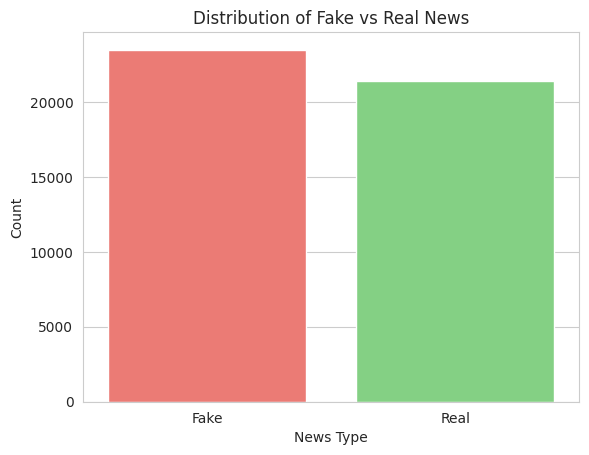

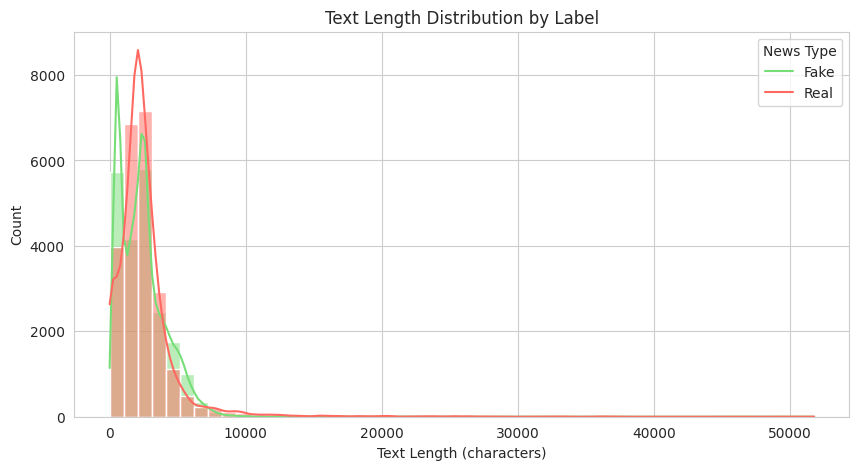

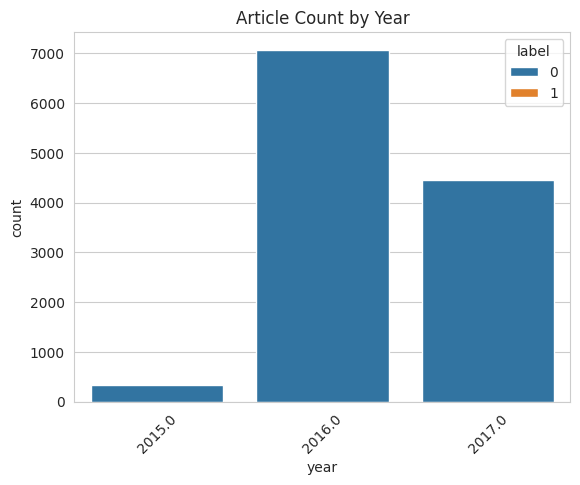


Missing values per column:

title              0
text               0
subject            0
date           33030
label              0
text_length        0
year           33030
dtype: int64


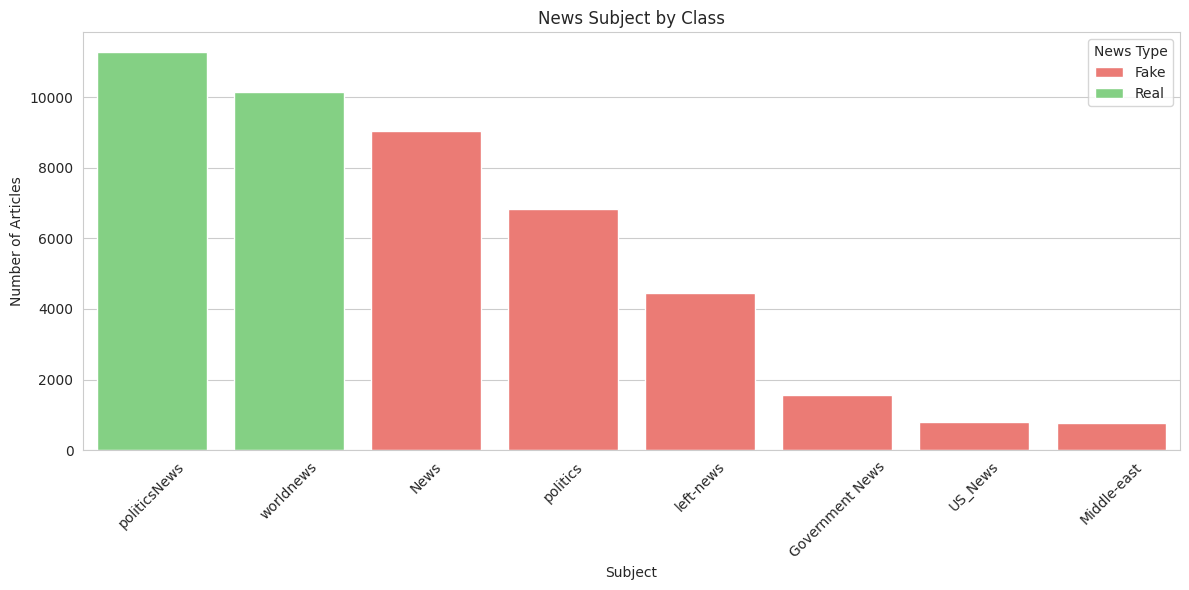

In [4]:
# 📊 Class distribution
sns.countplot(data=df, x='label', hue='label', palette={0: '#FF6961', 1: '#77DD77'}, legend=False)
plt.xticks(ticks=[0, 1], labels=['Fake', 'Real'])
plt.title('Distribution of Fake vs Real News')
plt.xlabel('News Type')
plt.ylabel('Count')
plt.show()

# 🧮 Basic stats about text length
df['text_length'] = df['text'].apply(len)

# 📈 Text length distribution with custom pastel colors
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x='text_length',
    hue='label',
    bins=50,
    kde=True,
    palette={0: '#FF6961', 1: '#77DD77'}
)
plt.title("Text Length Distribution by Label")
plt.xlabel("Text Length (characters)")
plt.ylabel("Count")
plt.legend(title="News Type", labels=['Fake', 'Real'])
plt.show()

# 🗓️ Check for publication date if available
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['year'] = df['date'].dt.year
    sns.countplot(data=df, x='year', hue='label')
    plt.title("Article Count by Year")
    plt.xticks(rotation=45)
    plt.show()

# 📚 Check for missing values
print("\nMissing values per column:\n")
print(df.isnull().sum())

# 📂 Subject column inspection (custom color + sorted)
if 'subject' in df.columns:
    plt.figure(figsize=(12, 6))

    # 📊 Count subject-label combinations
    subject_counts = df.groupby(['subject', 'label']).size().reset_index(name='count')

    # 🔄 Map label values
    subject_counts['News Type'] = subject_counts['label'].map({0: 'Fake', 1: 'Real'})

    # 📉 Sort by total count per subject
    order = (
        df['subject']
        .value_counts()
        .sort_values(ascending=False)
        .index
    )

    # 📈 Plot
    sns.barplot(data=subject_counts, x='subject', y='count', hue='News Type',
                palette={'Fake': '#FF6961', 'Real': '#77DD77'}, order=order)

    plt.title("News Subject by Class")
    plt.xlabel("Subject")
    plt.ylabel("Number of Articles")
    plt.xticks(rotation=45)
    plt.legend(title="News Type")
    plt.tight_layout()
    plt.show()


In [5]:
# Get top 10 most frequent titles
top_titles = df['title'].value_counts().head(10).index

# Filter dataset to include only those titles
top_df = df[df['title'].isin(top_titles)]

# Group by title and label to count occurrences in each class
label_counts = top_df.groupby(['title', 'label']).size().unstack(fill_value=0)

# Determine the dominant label (Fake=0, Real=1)
label_counts['Label'] = label_counts.apply(lambda row: 'Fake' if row[0] >= row[1] else 'Real', axis=1)

# Add total count for sorting
label_counts['Count'] = label_counts[0] + label_counts[1]

# Reset index and order columns
final_df = label_counts.reset_index()[['title', 'Count', 'Label']]
final_df.columns = ['Title', 'Count', 'Fake/Real']

# Display the result
import pandas as pd
from IPython.display import display
print("📋 Top 10 Most Frequent News Titles by Fake/Real Label\n")
display(final_df.sort_values(by='Count', ascending=False))


📋 Top 10 Most Frequent News Titles by Fake/Real Label



,Title,Count,Fake/Real
5,Factbox: Trump fills top jobs for his administ...,14,Real
2,Factbox: Contenders for senior jobs in Trump's...,8,Real
6,Highlights: The Trump presidency on April 13 a...,8,Real
4,Factbox: International reaction to arrest of R...,6,Real
9,MEDIA IGNORES Time That Bill Clinton FIRED His...,6,Fake
3,"Factbox: Contenders, picks for key jobs in Tru...",5,Real
7,Highlights: The Trump presidency on April 21 a...,5,Real
8,Highlights: The Trump presidency on March 31 a...,5,Real
0,ELEMENTARY SCHOOL PLANS ‘BLACKS ONLY’ FIELD TR...,4,Fake
1,FORMER FBI ASST DIRECTOR: “Jim Comey ‘Danced W...,4,Fake


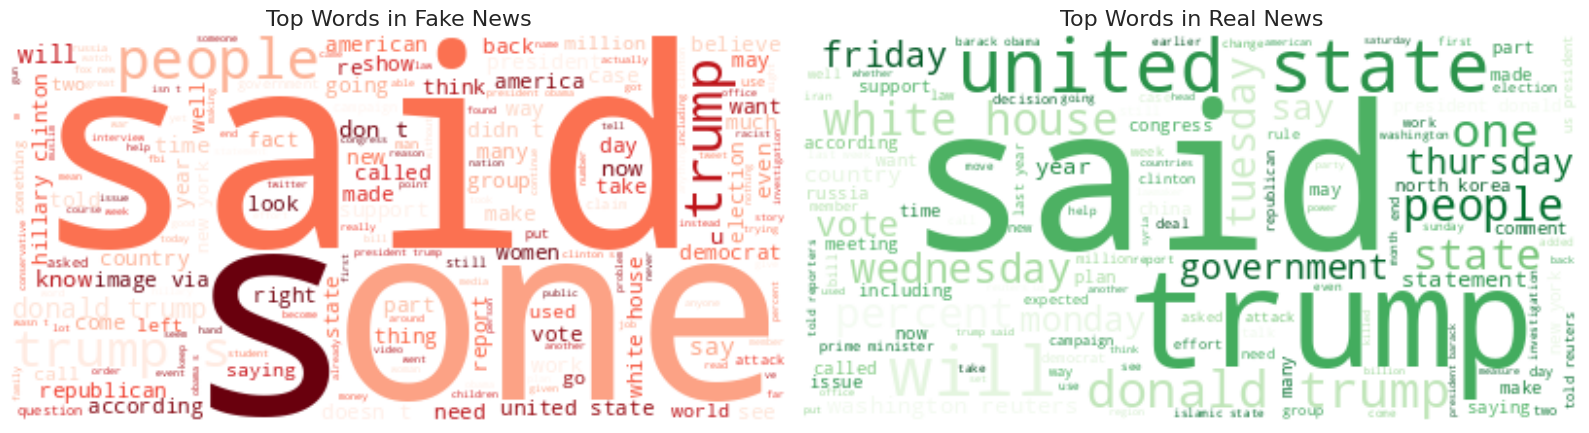

In [6]:
from wordcloud import WordCloud, STOPWORDS

# basic text preprocessing
def clean_for_wordcloud(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # remove URLs
    text = re.sub(r"[^a-z\s]", '', text)  # remove punctuation and numbers
    text = re.sub(r"\s+", ' ', text).strip()  # clean extra whitespace
    return text

# Prepare cleaned text
fake_text = " ".join(df[df['label'] == 0]['text'].apply(clean_for_wordcloud))
real_text = " ".join(df[df['label'] == 1]['text'].apply(clean_for_wordcloud))

# Generate word clouds
wc_fake = WordCloud(stopwords=STOPWORDS, background_color='white', colormap='Reds', max_words=200).generate(fake_text)
wc_real = WordCloud(stopwords=STOPWORDS, background_color='white', colormap='Greens', max_words=200).generate(real_text)

# Plot side-by-side
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.imshow(wc_fake, interpolation='bilinear')
plt.axis('off')
plt.title("Top Words in Fake News", fontsize=16)

plt.subplot(1, 2, 2)
plt.imshow(wc_real, interpolation='bilinear')
plt.axis('off')
plt.title("Top Words in Real News", fontsize=16)

plt.tight_layout()
plt.show()


---

## 🔹 4. Text Preprocessing

In this step, we clean and prepare the raw text for feature extraction. Key actions include:
- **Trimming article text** to the first 200 words to reduce noise and standardize length
- **Combining** the `title` and trimmed `text` into a single `combined_text` column
- **Filling missing values** in `title` and `text` fields
- Basic normalization (e.g., lowercasing, removing excess whitespace)

This streamlined preprocessing approach helps reduce overfitting while preserving important contextual information for classification.

---


In [7]:
# Combine title + first 200 words of text to reduce overfitting and size
df['text_trimmed'] = df['text'].apply(lambda x: ' '.join(x.split()[:200]))
df['combined_text'] = df['title'] + " " + df['text_trimmed']

# Features and target
X_text = df['combined_text']
y = df['label']


---

## 🔹 5. Feature Extraction using TF-IDF

After preprocessing, we convert the textual data into numerical format using **TF-IDF Vectorization**, which captures the importance of words while down-weighting common terms.

In this step:
- Apply `TfidfVectorizer` from `scikit-learn` on the `combined_text` column  
  → Use **unigrams and bigrams**, `max_features=1000`, `min_df=5`
- Split the dataset into **training** and **testing** sets (80/20 stratified)
- Apply **Random OverSampling** to balance the training data
- Generate the final feature matrix `X` and label vector `y` for model training

This ensures the model has balanced and informative input features.

---


In [8]:
# Ensure no missing values
df['title'] = df['title'].fillna("")
df['text'] = df['text'].fillna("")

# Combine title + trimmed text
df['text_trimmed'] = df['text'].apply(lambda x: ' '.join(x.split()[:200]))
df['combined_text'] = df['title'] + " " + df['text_trimmed']

# Features and target
X_text = df['combined_text']
y = df['label']

# Split into train/test
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=42
)

# Oversample training set
train_df = pd.DataFrame({'text': X_train_text, 'label': y_train})
ros = RandomOverSampler(random_state=42)
train_oversampled, y_train_bal = ros.fit_resample(train_df[['text']], train_df['label'])
X_train_text_bal = train_oversampled['text']

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=5)
X_train = tfidf.fit_transform(X_train_text_bal)
X_test = tfidf.transform(X_test_text)

---

## 🔹 6. Model Building & Evaluation

With the TF-IDF feature matrix and target labels prepared, we now build and evaluate multiple machine learning models to classify news as **FAKE** or **REAL**.

**Steps:**
- Train several classifiers on the oversampled training set:
  - **XGBoost** ✅ (Main Model)
  - Logistic Regression
  - Random Forest
  - Naive Bayes
- Evaluate each model on the test set using:
  - **Accuracy**
  - **Precision, Recall, F1-score**
  - **Confusion Matrix**
  - **ROC-AUC Score**
- Visualize model performance using bar charts and a confusion matrix heatmap

This allows us to compare models and select the best one for tuning and deployment.

---



📊 Model Comparison:
                 Model  Accuracy   ROC AUC
0        Random Forest  0.997439  0.999753
1          Naive Bayes  0.945100  0.987188
2  Logistic Regression  0.988085  0.999041
3              XGBoost  0.997327  0.999704


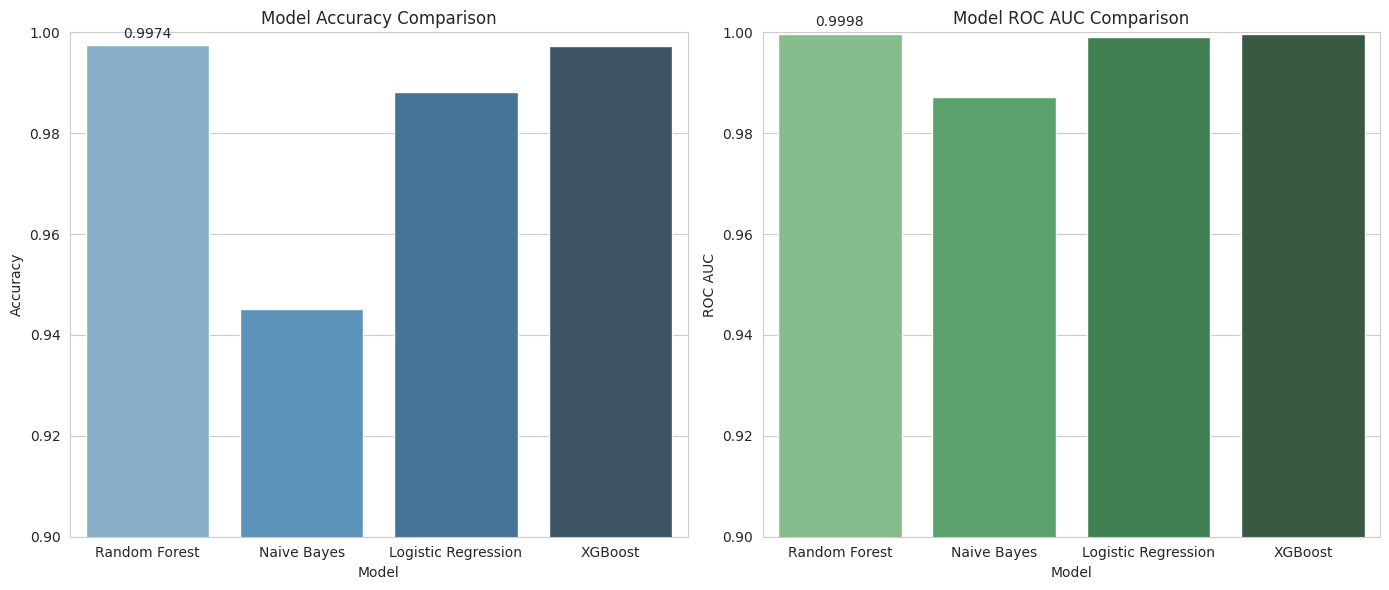

In [9]:
# Initialize and train models
rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
rf.fit(X_train, y_train_bal)

nb = MultinomialNB()
nb.fit(X_train, y_train_bal)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train_bal)

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train_bal)

# Predictions and probabilities
models = {
    "Random Forest": rf,
    "Naive Bayes": nb,
    "Logistic Regression": lr,
    "XGBoost": xgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results)

# Print results
print("\n📊 Model Comparison:")
print(results_df)

# Accuracy & ROC AUC Charts
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy Chart
acc_plot = sns.barplot(data=results_df, x='Model', y='Accuracy', ax=axes[0], hue='Model', palette="Blues_d", legend=False)
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_ylim(0.9, 1.0)
acc_plot.bar_label(acc_plot.containers[0], fmt='%.4f', padding=3)

# ROC AUC Chart
roc_plot = sns.barplot(data=results_df, x='Model', y='ROC AUC', ax=axes[1], hue='Model', palette="Greens_d", legend=False)
axes[1].set_title("Model ROC AUC Comparison")
axes[1].set_ylim(0.9, 1.0)
roc_plot.bar_label(roc_plot.containers[0], fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()


Fitting 5 folds for each of 10 candidates, totalling 50 fits


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:07:25] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔍 Tuned XGBoost Results:
[[4682   14]
 [   8 4276]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

ROC AUC Score: 0.9996876128361623


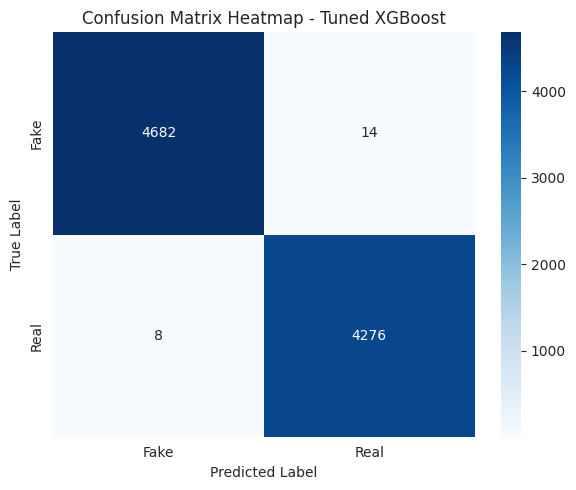

In [12]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_grid,
    n_iter=10,
    scoring='accuracy',
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train_bal)
best_xgb = xgb_search.best_estimator_

# Evaluate tuned model
y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("\n🔍 Tuned XGBoost Results:")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_xgb))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
labels = ['Fake', 'Real']
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap - Tuned XGBoost')
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:18:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:19:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:19:29] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:19:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:20:06] WARNING: /w

📊 CV Accuracy Scores: [0.99707213 0.99693905 0.99614054 0.99813681 0.99800373]
📈 Mean Accuracy: 0.997258450891669
📉 Standard Deviation: 0.0007366703488473775


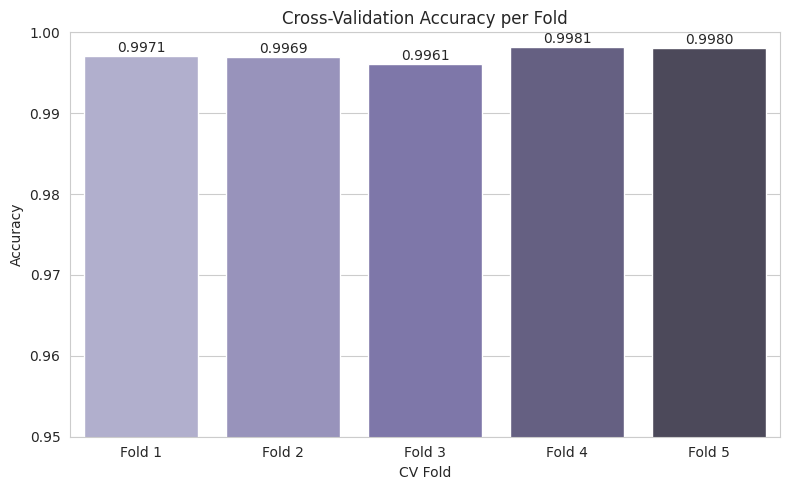

In [14]:
cv_scores = cross_val_score(best_xgb, X_train, y_train_bal, cv=5, scoring='accuracy')
print("📊 CV Accuracy Scores:", cv_scores)
print("📈 Mean Accuracy:", cv_scores.mean())
print("📉 Standard Deviation:", cv_scores.std())

plt.figure(figsize=(8, 5))
folds = [f"Fold {i+1}" for i in range(len(cv_scores))]
sns.barplot(x=folds, y=cv_scores, hue=folds, palette="Purples_d", legend=False)
plt.ylim(0.95, 1.0)
plt.title("Cross-Validation Accuracy per Fold")
plt.ylabel("Accuracy")
plt.xlabel("CV Fold")
for i, score in enumerate(cv_scores):
    plt.text(i, score + 0.0005, f"{score:.4f}", ha='center')
plt.tight_layout()
plt.show()


In [13]:
import json
import numpy as np

# === Save TF-IDF parameters and vocabulary ===
raw_params = tfidf.get_params()
clean_params = {}

# Only keep JSON-serializable parameters
for key, value in raw_params.items():
    try:
        json.dumps(value)
        clean_params[key] = value
    except TypeError:
        pass

# Convert int64 to int for JSON compatibility
clean_vocab = {k: int(v) for k, v in tfidf.vocabulary_.items()}

# === Save parameters and vocabulary ===
with open("tfidf_params.json", "w") as f:
    json.dump(clean_params, f)

with open("tfidf_vocab.json", "w") as f:
    json.dump(clean_vocab, f)

# === NEW: Save idf_ and stop_words_ ===
idf_values = tfidf.idf_.tolist()
with open("tfidf_idf.json", "w") as f:
    json.dump(idf_values, f)

# stop_words_ may not always exist
try:
    stop_words = list(tfidf.stop_words_)
except AttributeError:
    stop_words = []

with open("tfidf_stopwords.json", "w") as f:
    json.dump(stop_words, f)

print("✅ All TF-IDF config files saved (params, vocab, idf, stopwords).")


✅ All TF-IDF config files saved (params, vocab, idf, stopwords).


---

## 🔹 7. Model Comparison & Saving the Best Model

We have trained and evaluated four classification models:
- **XGBoost** ✅ (Best Performing)
- Logistic Regression
- Random Forest
- Naive Bayes

### 🏁 Performance Summary:
- **XGBoost** achieved the highest accuracy and ROC AUC score, making it the top model for deployment.
- Logistic Regression and Random Forest also showed strong performance.
- Naive Bayes served as a fast, lightweight baseline model.

### ✅ Next Steps:
- Save the best-performing model (**XGBoost Classifier**) using `joblib`.
- Save the fitted **TF-IDF vectorizer** to ensure consistent preprocessing during deployment.
- These saved artifacts (`model.pkl`, `tfidf.pkl`) are essential for integrating the model into the Streamlit web app.

---


In [15]:
# === Step 7B: Save the trained model using joblib
import joblib
joblib.dump(best_xgb, "fakenews_model.pkl", compress=("zlib", 3))
print("✅ Trained model saved.")


✅ Trained model saved.


In [ ]:
import sklearn
print(sklearn.__version__)

1.1.3


## 🔹 8. Conclusion & Next Steps

### ✅ Summary of Findings

In this project, we developed a complete end-to-end machine learning pipeline to detect **fake news** based on article content. Here's a summary of the major steps and outcomes:

- Used a labeled dataset of **fake and real news articles** from [Kaggle](https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset)
- Performed detailed **EDA** to explore label distribution, text patterns, and word frequencies
- Applied **text preprocessing** by trimming articles and combining `title` + `text` fields
- Converted text into features using **TF-IDF Vectorization** with unigrams and bigrams
- Addressed class imbalance with **Random OverSampling** on the training set
- Trained and evaluated multiple models:
  - ✅ **XGBoost** delivered the **best performance** across all metrics
  - Logistic Regression, Random Forest, and Naive Bayes were used for comparison
- Saved the final **XGBoost model** and **TF-IDF vectorizer** for deployment
- Deployed the solution as a **Streamlit web application** with real-time prediction capability

---

### 💡 Business Impact

This solution can assist in combating misinformation by:
- Helping **newsrooms** verify article authenticity efficiently
- Supporting **social media platforms** with automated content moderation
- Empowering **fact-checkers and the public** with quick article credibility checks

---

### 🚀 Next Steps & Future Improvements

Potential areas for enhancement include:

1. **Model Improvements**
   - Explore advanced models like **Logistic Regression with class weighting**, **LightGBM**, or **BERT**
   - Fine-tune TF-IDF settings or apply **word embeddings** (e.g., Word2Vec)

2. **Model Interpretability**
   - Integrate **SHAP** or **LIME** for explainable AI
   - Highlight influential words behind predictions in the UI

3. **App Feature Expansion**
   - Add support for **news scraping APIs** and **file uploads**
   - Enable **batch predictions** for bulk article processing

4. **Multilingual Support**
   - Extend capabilities to detect fake news in **non-English** articles

5. **Sentiment & Bias Analysis**
   - Incorporate **sentiment scoring** and **political bias detection** for richer insights

---

### 📦 Final Deliverables

- ✅ Cleaned and merged dataset (`Fake.csv`, `True.csv`)
- ✅ Oversampled training data for balanced learning
- ✅ TF-IDF feature extractor (`tfidf.pkl`)
- ✅ Trained XGBoost model (`model.pkl`)
- ✅ Deployed Streamlit app for live predictions
- ✅ Evaluation results: metrics, confusion matrix, ROC-AUC, and model comparison charts

---


---

## 🔹 9. Streamlit Integration & App Plan

We now prepare the trained model for deployment using **Streamlit**, a lightweight Python framework that allows for rapid development and sharing of interactive data applications.

---

### ✅ App Features

- Text input box to enter a news article (title + content)
- Prediction result: **Real 👍** or **Fake 👎**
- (Optional) Confidence score display
- Simple, clean, and interactive web interface

---

### 🛠️ Required Files

- `model.pkl` → Trained **XGBoost** model
- `tfidf.pkl` → Fitted **TF-IDF Vectorizer**
- `app.py` → Streamlit script for user input and model prediction
- `requirements.txt` → Dependencies for deployment (e.g., `streamlit`, `scikit-learn`, `xgboost`, `joblib`)

---

### ☁️ Deployment via Streamlit Cloud

Steps:
1. Push the project files to a **GitHub repository**
2. Go to [https://streamlit.io/cloud](https://streamlit.io/cloud)
3. Link your GitHub repo and select:
   - Main file: `app.py`
4. Click **Deploy**

Your app will be live at:  
`https://<your-username>-<repo-name>.streamlit.app`

---



In [ ]:
# Streamlit Link: https://fake-news-detector-82zm6mky62qo22enucirht.streamlit.app/

---

## 🔹 10. Streamlit Integration Plan

To make the Fake News Detection model accessible and interactive, we deployed it as a web application using **Streamlit Cloud**. This allows users to input any news headline or article content and instantly receive a prediction on whether the news is **FAKE** or **REAL**.

---

### 📊 App Workflow

The app follows a straightforward and intuitive pipeline:

1. **User Input**  
   → The user enters a news article (title + text) into a text box

2. **Text Preprocessing**  
   → Input is cleaned and formatted as per the training pipeline

3. **TF-IDF Transformation**  
   → The preprocessed text is vectorized using the saved TF-IDF model (`tfidf.pkl`)

4. **Model Prediction**  
   → The vectorized input is passed to the saved **XGBoost** model (`model.pkl`) for classification

5. **Output Display**  
   → The app returns the predicted label:  
   ✅ *REAL News* or ❌ *FAKE News*  
   Optionally, a confidence score or explanation can be displayed

---

This deployed solution enables real-time interaction and demonstrates the practical use of machine learning and NLP for addressing misinformation.

---


In [5]:
# 📋 Print some examples to manually test the Streamlit app

print("🔹 5 FAKE News Samples (Original Text Only):\n")
fake_samples = df[df['label'] == 0].sample(5, random_state=40)

for idx, row in fake_samples.iterrows():
    print(f"📰 Title: {row['title']}")
    print(f"📜 Text (first 300 chars):\n{row['text'][:300]}")
    print("-" * 100)

print("🔹 5 REAL News Samples (Original Text Only):\n")
real_samples = df[df['label'] == 1].sample(5, random_state=40)

for idx, row in real_samples.iterrows():
    print(f"📰 Title: {row['title']}")
    print(f"📜 Text (first 300 chars):\n{row['text'][:300]}")
    print("-" * 100)

🔹 5 FAKE News Samples (Original Text Only):

📰 Title:  After Being Handed Yet Another Court Loss, Trump Threatens Revenge In Pure Dictator Style
📜 Text (first 300 chars):
Donald Trump hates losing. Not because it s a loss to his agenda, or a perceived loss to the American people. Trump hates losing because it hurt his paper thin ego and when he does lose, there s hell to pay (or at least threatened hell to pay). Trump suffered another major loss in court after a 9th 
----------------------------------------------------------------------------------------------------
📰 Title: WHY Did Hillary Use FAKE NAME “Diane Reynolds” For Chelsea In Newly Released Emails That PROVE She Lied About Benghazi? [VIDEO]
📜 Text (first 300 chars):
What a role model for mothers in America or at least for the ones who have FAKE NAMES for their daughters when they use private servers to cover up their corrupt behavior Wikileaks found 67 emails between Hillary Clinton and daughter Chelsea under her fake name,  

In [6]:
# 📋 Print some examples to manually test the Streamlit app

print("🔹 5 FAKE News Samples (Original Text Only):\n")
fake_samples = df[df['label'] == 0].sample(5, random_state=39)

for idx, row in fake_samples.iterrows():
    print(f"📰 Title: {row['title']}")
    print(f"📜 Text (first 300 chars):\n{row['text'][:300]}")
    print("-" * 100)

print("🔹 5 REAL News Samples (Original Text Only):\n")
real_samples = df[df['label'] == 1].sample(5, random_state=39)

for idx, row in real_samples.iterrows():
    print(f"📰 Title: {row['title']}")
    print(f"📜 Text (first 300 chars):\n{row['text'][:300]}")
    print("-" * 100)

🔹 5 FAKE News Samples (Original Text Only):

📰 Title: (VIDEO) OBAMA GOES OFF THE RAILS AND CLAIMS THAT BRAZIL AND THE U.S. HAVE SIMILAR HISTORIES
📜 Text (first 300 chars):
Does this president know American history or does he just make it up? Who writes this bs for him? Whoever it is needs to be canned! Brazil was a dictatorship and under military rule until 1985!Could someone pass along the Wikipedia info on Brazil to Obama? 
----------------------------------------------------------------------------------------------------
📰 Title:  Trump Blames Baton Rouge Police Shooting On Obama’s ‘Lack Of Leadership’ (TWEETS)
📜 Text (first 300 chars):
Following the tragic shooting of several police officers in Baton Rouge, Louisiana earlier today that left three officers dead and three more injured, Republican presidential candidate Donald Trump took the tragedy as an opportunity to bash President Barack Obama and make a pathetic attempt to convi
--------------------------------------------------